 # Regression-based error attribution (Zhong et al. 2023)



 Follows Zhong et al. (2023, Sci. Adv.): source-region (africa, amazon)

 Fig. 3-style AAOD error decomposition. African outflow AAOD is a meta-model

 prediction target (Supplementary Text 2), not a load/emission lifetime

 decomposition.



 Key equations:

 - `AAOD = E * tau * MAC`

 - `1/tau = A + alpha * Pr + beta * AE`

 - `MAC = F * SSA` (+ intercept if `INTERCEPT_0` is False)

 - `E_C = AAOD_obs / (tau_C * MAC_C)`

 - Outflow: `AAOD_out = a*(E*tau*MAC) + b*(E*tau) + c*MAC + d`



 Configuration flags (defaults):

 - `INTERCEPT_0 = False` — OLS with intercept; `True` forces through origin

 - `POLDER_HOMOGENIZE = True` — Zhong et al. regional AAOD homogenization

 - Amazon SOA always included via paper ~52% fraction of total OA



 Run: `.venv/bin/python notebooks/error_attribution.py`

 NEED TO FIX the data loading of monthly data

In [17]:
import sys
import os
from pathlib import Path
import pickle
import warnings
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import linregress
from xarray.coding.times import decode_cf_datetime

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Project paths
try:
    project_root = Path(__file__).resolve().parent.parent
except NameError:
    project_root = Path('/scistor/guest/gbb083/AeroCom')
py_dir = project_root / 'py'
if str(py_dir) not in sys.path:
    sys.path.insert(0, str(py_dir))

import functions
import cameo_toolbox as ct
import aerocom_data

print(f'Project root: {project_root}')
print(f'Python dir:   {py_dir}')


# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
EXCLUDE_MODELS = []  # e.g. ['GEOS-i33p2-met2010_AP3-CTRL']

# Derived variables computed after regional/temporal aggregation.
DERIVED_VAR_AFTER_AGG = ['lifetime']

# Lifetime outlier filtering at grid-cell level (disabled when lifetime is
# computed after aggregation).
LIFETIME_MAX_DAYS = 365
LIFETIME_MIN_DAYS = 1e-3
if any(v in DERIVED_VAR_AFTER_AGG for v in ('lifetime', 'lifetime_BC_OA')):
    LIFETIME_MAX_DAYS = None
    LIFETIME_MIN_DAYS = None

POST_AGG_LIFETIME_MAX_DAYS = None
POST_AGG_LIFETIME_MIN_DAYS = None

SAVE_FIGURE = False
USE_PICKLE = False

# MAC–SSA regression:
#   INTERCEPT_0 = False -> MAC = F * SSA + intercept  (OLS; default)
#   INTERCEPT_0 = True  -> MAC = F * SSA              (through origin)
INTERCEPT_0 = False

# Zhong et al. POLDER-GRASP homogenization of regional AAOD used for E_C.
POLDER_HOMOGENIZE = True

# Amazon SOA: no dedicated emisoa variable in AP3_processed_monthly.
# Zhong et al. (2023) estimate SOA ≈ 52% of total OA over the Amazon.
# Treat model emioa as primary OA and scale so SOA/(POA+SOA) = AMAZON_SOA_FRACTION.
AMAZON_SOA_FRACTION = 0.52
INCLUDE_AMAZON_SOA = True  # always on for the main workflow; toggle only for debugging

# Source regions used for the main Fig. 3-style decomposition.
SOURCE_REGIONS = ['africa', 'amazon']
OUTFLOW_REGION = 'outflow_af'
OUTFLOW_SOURCE = 'africa'

PAPER_DECOMP = {
    'amazon': {'pct_MAC': 47},
    'africa': {'pct_E': 40, 'pct_MAC': 31},
}

print('\n--- Active configuration ---')
print(f'  INTERCEPT_0          = {INTERCEPT_0}  '
      f"({'through origin' if INTERCEPT_0 else 'OLS with intercept'})")
print(f'  POLDER_HOMOGENIZE    = {POLDER_HOMOGENIZE}')
print(f'  INCLUDE_AMAZON_SOA   = {INCLUDE_AMAZON_SOA}  '
      f'(fraction={AMAZON_SOA_FRACTION:.0%} of total OA)')
print(f'  EXCLUDE_MODELS      = {EXCLUDE_MODELS}')
print(f'  DERIVED_VAR_AFTER_AGG= {DERIVED_VAR_AFTER_AGG}')
print(f'  SAVE_FIGURE          = {SAVE_FIGURE}')



Project root: /scistor/guest/gbb083/AeroCom
Python dir:   /scistor/guest/gbb083/AeroCom/py

--- Active configuration ---
  INTERCEPT_0          = False  (OLS with intercept)
  POLDER_HOMOGENIZE    = True
  INCLUDE_AMAZON_SOA   = True  (fraction=52% of total OA)
  EXCLUDE_MODELS      = []
  DERIVED_VAR_AFTER_AGG= ['lifetime']
  SAVE_FIGURE          = False


 ## Load monthly model data

In [2]:
VARIABLES = [
    'abs550aer', 'depbc', 'depdust', 'depoa', 'depso2', 'depso4', 'depss',
    'emibc', 'emidust', 'emioa', 'emiso2', 'emiss', 'loadbc', 'loaddust',
    'loadoa', 'loadso2', 'loadso4', 'loadss', 'od440aer', 'od550aer',
    'od870aer', 'od865aer', 'od550bc', 'od550dust', 'od550oa', 'od550so4', 'od550ss',
    'precip',
]

if USE_PICKLE:
    monthly_pickle = project_root / 'Data' / 'var_files' / 'original' / 'monthly' / 'monthly_aerocom_data.pickle'
    print(f'Loading monthly pickle: {monthly_pickle}')
    with open(monthly_pickle, 'rb') as f:
        raw_data = pickle.load(f)
else:
    print('Loading monthly data from processed NetCDF files...')
    raw_data = aerocom_data.load_monthly_data_from_netcdf(
        output_base_dir=str(project_root / 'Data' / 'AP3_processed_monthly'),
        variables=VARIABLES,
    )

missing_excluded = [m for m in EXCLUDE_MODELS if m not in raw_data]
if missing_excluded:
    print(f'Warning: excluded models not found in data: {missing_excluded}')
models = sorted([m for m in raw_data.keys() if m not in EXCLUDE_MODELS])
actually_excluded = [m for m in EXCLUDE_MODELS if m in raw_data]
print(f'Number of models: {len(models)} (excluded {len(actually_excluded)}: {actually_excluded})')

# Document SOA availability in processed NetCDF
_available_vars = sorted({
    p.name for p in (project_root / 'Data' / 'AP3_processed_monthly').iterdir()
    if p.is_dir()
}) if (project_root / 'Data' / 'AP3_processed_monthly').exists() else []
_soa_like = [v for v in _available_vars if 'soa' in v.lower() or 'seco' in v.lower()]
print(f'Processed monthly variables: {len(_available_vars)} directories')
if _soa_like:
    print(f'  Found SOA-like directories: {_soa_like}')
else:
    print('  No dedicated SOA / secondary-OA emission directory found; '
          f'using Amazon SOA fraction approximation ({AMAZON_SOA_FRACTION:.0%}).')



Loading monthly data from processed NetCDF files...
Loaded 407 NetCDF files for 19 models from /scistor/guest/gbb083/AeroCom/Data/AP3_processed_monthly
Number of models: 19 (excluded 0: [])
Processed monthly variables: 28 directories
  No dedicated SOA / secondary-OA emission directory found; using Amazon SOA fraction approximation (52%).


 ## Normalize time and build combined variables

In [3]:
def normalize_dataset_time(ds, var_hint=None):
    """Normalize time coordinate of a dataset to first-of-month."""
    if ds is None or not list(ds.data_vars):
        return None
    var_name = list(ds.data_vars)[0]
    da = ds[var_name]
    if 'time' not in da.dims or len(da.time) == 0:
        return ds

    if var_hint and 'GEOS' in str(var_hint).upper():
        try:
            ds = xr.decode_cf(ds)
            da = ds[var_name]
        except Exception as e:
            print(f'  Warning: GEOS decode_cf failed for {var_hint}: {e}')

    def _to_month_start(values):
        try:
            return pd.to_datetime(values).to_period('M').to_timestamp().values
        except Exception:
            return np.array([
                np.datetime64(f'{t.year:04d}-{t.month:02d}-01', 'ns')
                for t in values
            ])

    if not isinstance(da.time.values[0], (np.datetime64, pd.Timestamp)):
        try:
            raw = da.time.values
            if raw.dtype.kind in 'iuf' and np.all(raw > 100000) and np.all(raw < 999999):
                pass
            elif 'units' in da.time.attrs:
                try:
                    new_times = decode_cf_datetime(
                        da.time.values,
                        da.time.attrs.get('units'),
                        da.time.attrs.get('calendar', 'standard'),
                    )
                except Exception:
                    new_times = pd.to_datetime([str(t) for t in da.time.values]).values
                da = da.assign_coords(time=new_times)
            elif hasattr(da.indexes.get('time', None), 'to_datetimeindex'):
                try:
                    new_times = da.indexes['time'].to_datetimeindex().values
                except OverflowError:
                    new_times = np.array([
                        np.datetime64(f'{t.year:04d}-{t.month:02d}-01', 'ns')
                        for t in da.indexes['time']
                    ])
                da = da.assign_coords(time=new_times)
            else:
                da = da.assign_coords(
                    time=pd.to_datetime([str(t) for t in da.time.values]).values
                )
        except Exception as e:
            print(f'  Warning: cftime conversion failed for {var_hint}: {e}')
            return ds

    da = functions.normalize_monthly_time(da)
    da = da.assign_coords(time=_to_month_start(da.time.values))
    return da.to_dataset(name=var_name)


def sum_datasets(model_data, keys, out_name):
    """Sum a list of variables (Datasets) into a new Dataset, skipping missing ones."""
    dsets = [model_data[k] for k in keys if model_data.get(k) is not None]
    if not dsets:
        return None
    arrays = [d[list(d.data_vars)[0]] for d in dsets]
    total = arrays[0].copy()
    for a in arrays[1:]:
        total = total + a
    return total.to_dataset(name=out_name)


def normalize_precipitation_units(precip_ds):
    """Convert model precipitation to mm day^-1."""
    if precip_ds is None:
        return None
    var_name = list(precip_ds.data_vars)[0]
    da = precip_ds[var_name]
    units = da.attrs.get('units', 'kg m-2 s-1').lower().replace(' ', '')
    if units in ('kgm-2s-1', 'kgm^-2s^-1', 'kg/m2/s', 'kgm-2s-1'):
        factor = 86400.0
    elif units in ('gm-2s-1', 'gm^-2s^-1', 'g/m2/s', 'gm-2s-1'):
        factor = 86.4
    elif units in ('mmday-1', 'mm/day', 'mmday^-1', 'mmd-1'):
        factor = 1.0
    elif units in ('ms-1', 'm/s', 'm s-1'):
        factor = 86400.0 * 1000.0
    else:
        factor = 86400.0  # treat 'km m-2 s-1' typo as kg
    da = da * factor
    try:
        global_mean = float(da.mean().values)
    except Exception:
        global_mean = np.nan
    if not np.isnan(global_mean) and global_mean > 100.0:
        da = da / 1000.0
    da.attrs['units'] = 'mm day-1'
    return da.to_dataset(name=var_name)


LOAD_VARS = ['loadbc', 'loaddust', 'loadoa', 'loadso4', 'loadss']
EMI_VARS = ['emibc', 'emidust', 'emioa', 'emiso2', 'emiss']
BC_OA_LOAD = ['loadbc', 'loadoa']
BC_OA_EMI = ['emibc', 'emioa']

data = {}
for m in models:
    normalized = {}
    for var in VARIABLES:
        if raw_data[m].get(var) is None:
            continue
        try:
            normalized[var] = normalize_dataset_time(raw_data[m][var], var_hint=f'{m}/{var}')
        except Exception as e:
            print(f'  Failed to normalize {m}/{var}: {e}')
            normalized[var] = None
    normalized['load_total'] = sum_datasets(normalized, LOAD_VARS, 'load_total')
    normalized['emi_total'] = sum_datasets(normalized, EMI_VARS, 'emi_total')
    normalized['load_BC_OA'] = sum_datasets(normalized, BC_OA_LOAD, 'load_BC_OA')
    # Primary BC+OA only here; Amazon SOA is applied after regional aggregation.
    normalized['emi_BC_OA'] = sum_datasets(normalized, BC_OA_EMI, 'emi_BC_OA')
    if normalized.get('precip') is not None:
        normalized['precip'] = normalize_precipitation_units(normalized['precip'])
    data[m] = normalized

print('Time coordinates normalized; total/BC+OA load and primary emissions built.')



Time coordinates normalized; total/BC+OA load and primary emissions built.


 ## Calculate derived variables

In [4]:
def filter_lifetime(da, model_name, var_name, max_days=None, min_days=None):
    """Mask unrealistic lifetime values (NaN, inf, outside thresholds)."""
    if da is None:
        return None, {'n_total': 0, 'n_excluded': 0}
    if max_days is None and min_days is None:
        return da, {'n_total': int(da.size), 'n_excluded': 0}
    bad = np.isnan(da) | np.isinf(da)
    if max_days is not None:
        bad = bad | (da > max_days)
    if min_days is not None:
        bad = bad | (da < min_days)
    n_excluded = int(bad.sum())
    if n_excluded:
        print(f'  Lifetime filter: {model_name} {var_name} excluded {n_excluded:,} / {da.size:,} values '
              f'({n_excluded / da.size * 100:.2f}%) outside [{min_days}, {max_days}] days')
    return da.where(~bad), {'n_total': int(da.size), 'n_excluded': n_excluded}


derived_vars_pre = [dv for dv in ['MEC', 'MAC', 'SSA', 'AE'] if dv not in DERIVED_VAR_AFTER_AGG]
derived = {m: {} for m in models}
lifetime_filter_stats = []

for m in models:
    for dv in derived_vars_pre:
        ds = aerocom_data.calculate_derived_var(data[m], m, dv)
        if ds is None:
            derived[m][dv] = None
        else:
            derived[m][dv] = ds[list(ds.data_vars)[0]]

    if 'lifetime_BC_OA' not in DERIVED_VAR_AFTER_AGG and 'lifetime' not in DERIVED_VAR_AFTER_AGG:
        if data[m].get('load_BC_OA') is not None and data[m].get('emi_BC_OA') is not None:
            load_da = data[m]['load_BC_OA']['load_BC_OA']
            emi_da = data[m]['emi_BC_OA']['emi_BC_OA']
            lt = load_da / (emi_da * 3600 * 24)
            lt, stats_lt = filter_lifetime(lt, m, 'lifetime_BC_OA', LIFETIME_MAX_DAYS, LIFETIME_MIN_DAYS)
            derived[m]['lifetime_BC_OA'] = lt
            lifetime_filter_stats.append({'model': m, 'var': 'lifetime_BC_OA', **stats_lt})
        else:
            derived[m]['lifetime_BC_OA'] = None

    if 'lifetime' not in DERIVED_VAR_AFTER_AGG:
        if data[m].get('load_total') is not None and data[m].get('emi_total') is not None:
            load_da = data[m]['load_total']['load_total']
            emi_da = data[m]['emi_total']['emi_total']
            lt = load_da / (emi_da * 3600 * 24)
            lt, stats_lt = filter_lifetime(lt, m, 'lifetime', LIFETIME_MAX_DAYS, LIFETIME_MIN_DAYS)
            derived[m]['lifetime'] = lt
            lifetime_filter_stats.append({'model': m, 'var': 'lifetime', **stats_lt})
        else:
            derived[m]['lifetime'] = None

if lifetime_filter_stats:
    total_excluded = sum(s['n_excluded'] for s in lifetime_filter_stats)
    total_cells = sum(s['n_total'] for s in lifetime_filter_stats)
    print(f'\nLifetime filter summary: excluded {total_excluded:,} / {total_cells:,} '
          f'grid-cell values ({total_excluded / max(total_cells, 1) * 100:.2f}%)')

data_derived = {}
for m in models:
    data_derived[m] = {}
    for k, v in data[m].items():
        if v is not None:
            data_derived[m][k] = v[list(v.data_vars)[0]]
    for k, v in derived[m].items():
        if v is not None:
            data_derived[m][k] = v

variables_pre_aggregated = [
    'MEC', 'MAC', 'SSA', 'AE', 'load_BC_OA', 'emi_BC_OA', 'load_total', 'emi_total',
    'precip', 'abs550aer', 'emibc', 'emioa',
]
print('\nDerived-variable availability (pre-aggregation):')
for dv in ['MEC', 'MAC', 'SSA', 'AE', 'lifetime', 'lifetime_BC_OA']:
    n = sum(1 for m in models if data_derived[m].get(dv) is not None)
    print(f'  {dv:15s}: {n:2d} / {len(models)} models')




Derived-variable availability (pre-aggregation):
  MEC            : 19 / 19 models
  MAC            : 15 / 19 models
  SSA            : 15 / 19 models
  AE             : 15 / 19 models
  lifetime       :  0 / 19 models
  lifetime_BC_OA :  0 / 19 models


 ## Regional masks and monthly aggregation

In [5]:
REGIONS = {
    'global': {
        'surface_type': 'all',
        'lon_range': (0, 360), 'lat_range': (-90, 90),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'africa': {
        'surface_type': 'land',
        'lon_range': (15, 37), 'lat_range': (-15, 0),
        'time_slice': ('2010-06-01', '2010-09-30'), 'edge_weighted': False,
    },
    'amazon': {
        'surface_type': 'land',
        'lon_range': (287, 317), 'lat_range': (-17, -3),
        'time_slice': ('2010-07-01', '2010-10-31'), 'edge_weighted': False,
    },
    'outflow_af': {
        'surface_type': 'ocean',
        'lon_range': (350, 8), 'lat_range': (-15, 3),
        'time_slice': ('2010-06-01', '2010-09-30'), 'edge_weighted': True,
    },
}

sample_model = next((m for m in models if data[m].get('od550aer') is not None), None)
template = data[sample_model]['od550aer'].isel(time=0)
print(f'Template grid from {sample_model}: {template.dims}')

SURFACE_TYPE = None
masks = {}
for name, cfg in REGIONS.items():
    masks[name] = ct.create_region_mask(
        template, region=name,
        surface_type=SURFACE_TYPE if SURFACE_TYPE is not None else cfg.get('surface_type', 'all'),
        mask_registry=masks,
    )
print('Regions created:', list(masks.keys()))


def aggregate_region(model_dict, var_name, region_name, return_time_series=False, skipna=False):
    """Spatially aggregate `var_name` for every model."""
    cfg = REGIONS[region_name]
    result = {}
    for model, model_data in model_dict.items():
        if var_name not in model_data or model_data[var_name] is None:
            continue
        try:
            result[model] = ct.regional_aggregate(
                model_data[var_name], masks[region_name],
                spatial='mean', edge_weighted=cfg['edge_weighted'],
                time_slice=cfg['time_slice'], temporal='mean',
                return_time_series=return_time_series, skipna=skipna,
            )
        except Exception as e:
            print(f'  Aggregation failed for {var_name} {model} {region_name}: {e}')
    return result


def compute_derived_after_aggregation(monthly_dict, seasonal_dict):
    """Compute lifetime-like variables from aggregated load/emission."""
    lifetime_after_agg = 'lifetime' in DERIVED_VAR_AFTER_AGG
    lifetime_bcoa_after_agg = lifetime_after_agg or 'lifetime_BC_OA' in DERIVED_VAR_AFTER_AGG

    if lifetime_bcoa_after_agg:
        for agg in (monthly_dict, seasonal_dict):
            for region in REGIONS:
                load = agg[region].get('load_BC_OA', {})
                emi = agg[region].get('emi_BC_OA', {})
                out = {}
                for model in load:
                    if model in emi:
                        try:
                            out[model] = load[model] / (emi[model] * 3600 * 24)
                        except Exception as e:
                            print(f'  Failed post-aggregation lifetime_BC_OA for {model} {region}: {e}')
                agg[region]['lifetime_BC_OA'] = out

    if lifetime_after_agg:
        for agg in (monthly_dict, seasonal_dict):
            for region in REGIONS:
                load = agg[region].get('load_total', {})
                emi = agg[region].get('emi_total', {})
                out = {}
                for model in load:
                    if model in emi:
                        try:
                            out[model] = load[model] / (emi[model] * 3600 * 24)
                        except Exception as e:
                            print(f'  Failed post-aggregation lifetime for {model} {region}: {e}')
                agg[region]['lifetime'] = out


def apply_amazon_soa(monthly_dict, seasonal_dict):
    """Add Amazon SOA into emi_BC_OA and recompute Amazon BC+OA lifetime.

    Approximation (Zhong et al. 2023): SOA is AMAZON_SOA_FRACTION of total OA,
    model ``emioa`` is treated as primary OA (POA):

        total_OA = POA / (1 - f)
        emi_BC_OA = emibc + total_OA
    """
    if not INCLUDE_AMAZON_SOA:
        print('\nAmazon SOA: SKIPPED (INCLUDE_AMAZON_SOA=False)')
        return

    f = AMAZON_SOA_FRACTION
    if not (0.0 < f < 1.0):
        raise ValueError(f'AMAZON_SOA_FRACTION must be in (0, 1), got {f}')

    print('\n--- Amazon SOA adjustment ---')
    print(f'  No dedicated SOA NetCDF variable found; using paper fraction f={f:.0%}.')
    print('  emi_BC_OA_amazon = emibc + emioa / (1 - f)')

    for agg_name, agg in (('seasonal', seasonal_dict), ('monthly', monthly_dict)):
        region = 'amazon'
        emibc = agg[region].get('emibc', {})
        emioa = agg[region].get('emioa', {})
        emi_adj = {}
        n = 0
        for model in set(emibc) | set(emioa):
            bc = emibc.get(model)
            oa = emioa.get(model)
            if bc is None or oa is None:
                continue
            try:
                # monthly may be DataArrays; seasonal are floats
                emi_adj[model] = bc + oa / (1.0 - f)
                n += 1
            except Exception as e:
                print(f'  SOA adjust failed ({agg_name}) {model}: {e}')
        if emi_adj:
            agg[region]['emi_BC_OA'] = {**agg[region].get('emi_BC_OA', {}), **emi_adj}
            # Recompute lifetime with SOA-adjusted emissions
            load = agg[region].get('load_BC_OA', {})
            lt = {}
            for model, emi in emi_adj.items():
                if model in load:
                    try:
                        lt[model] = load[model] / (emi * 3600 * 24)
                    except Exception:
                        pass
            if lt:
                agg[region]['lifetime_BC_OA'] = {
                    **agg[region].get('lifetime_BC_OA', {}), **lt
                }
        if agg_name == 'seasonal':
            vals = [float(v) if not hasattr(v, 'values') else float(np.asarray(v).mean())
                    for v in emi_adj.values()]
            if vals:
                print(f'  Seasonal Amazon emi_BC_OA after SOA: '
                      f'n={len(vals)}, mean={np.mean(vals):.3e} kg m^-2 s^-1')


def filter_lifetime_after_agg(monthly_dict, seasonal_dict, max_days=None, min_days=None):
    """Mask unphysical after-aggregation lifetime values with NaN."""
    if max_days is None and min_days is None:
        return
    for var in ['lifetime', 'lifetime_BC_OA']:
        for agg in (monthly_dict, seasonal_dict):
            for region in REGIONS:
                if var not in agg[region]:
                    continue
                for model, val in list(agg[region][var].items()):
                    try:
                        v = float(val) if not hasattr(val, 'values') else float(val.values)
                    except Exception:
                        continue
                    if (not np.isfinite(v)
                            or (max_days is not None and v > max_days)
                            or (min_days is not None and v < min_days)):
                        agg[region][var][model] = np.nan


variables_to_aggregate = [v for v in variables_pre_aggregated if v not in DERIVED_VAR_AFTER_AGG]
LIFETIME_VARS = {'lifetime_BC_OA', 'lifetime'}

model_monthly = {
    region: {
        var: aggregate_region(data_derived, var, region, return_time_series=True,
                              skipna=(var in LIFETIME_VARS))
        for var in variables_to_aggregate
    }
    for region in REGIONS
}
model_seasonal = {
    region: {
        var: aggregate_region(data_derived, var, region, return_time_series=False,
                              skipna=(var in LIFETIME_VARS))
        for var in variables_to_aggregate
    }
    for region in REGIONS
}

compute_derived_after_aggregation(model_monthly, model_seasonal)
apply_amazon_soa(model_monthly, model_seasonal)
filter_lifetime_after_agg(model_monthly, model_seasonal,
                          POST_AGG_LIFETIME_MAX_DAYS, POST_AGG_LIFETIME_MIN_DAYS)

print('\nModel seasonal availability:')
for region in SOURCE_REGIONS + [OUTFLOW_REGION]:
    for var in ['MAC', 'SSA', 'AE', 'lifetime_BC_OA', 'precip', 'abs550aer', 'emi_BC_OA']:
        n = len(model_seasonal[region].get(var, {}))
        print(f'  {region} {var}: {n} models')



Template grid from CAM5-ATRAS_AP3-CTRL: FrozenMappingWarningOnValuesAccess({'lon': 144, 'lat': 96})
Regions created: ['global', 'africa', 'amazon', 'outflow_af']

--- Amazon SOA adjustment ---
  No dedicated SOA NetCDF variable found; using paper fraction f=52%.
  emi_BC_OA_amazon = emibc + emioa / (1 - f)
  Seasonal Amazon emi_BC_OA after SOA: n=16, mean=3.270e-10 kg m^-2 s^-1

Model seasonal availability:
  africa MAC: 15 models
  africa SSA: 15 models
  africa AE: 15 models
  africa lifetime_BC_OA: 19 models
  africa precip: 19 models
  africa abs550aer: 15 models
  africa emi_BC_OA: 19 models
  amazon MAC: 15 models
  amazon SSA: 15 models
  amazon AE: 15 models
  amazon lifetime_BC_OA: 19 models
  amazon precip: 19 models
  amazon abs550aer: 15 models
  amazon emi_BC_OA: 19 models
  outflow_af MAC: 15 models
  outflow_af SSA: 15 models
  outflow_af AE: 15 models
  outflow_af lifetime_BC_OA: 19 models
  outflow_af precip: 19 models
  outflow_af abs550aer: 15 models
  outflow_af emi

 ## Regional map of study areas

In [6]:
print('\n--- Regional map ---')
sample_field = data[sample_model]['od550aer']['od550aer'].isel(time=0)
region_boxes = {
    name: (cfg['lon_range'][0], cfg['lon_range'][1], cfg['lat_range'][0], cfg['lat_range'][1])
    for name, cfg in REGIONS.items() if name != 'global'
}
fig = ct.fake_uba_map(
    lon=sample_field.lon.values,
    lat=sample_field.lat.values,
    c_array=sample_field.values,
    labels='AOD 550 (background)',
    title='Study regions',
    region_boxes=region_boxes,
    show_region_labels=True,
    region_edgecolor='magenta',
    region_linewidth=2.0,
    cbar_orientation='vertical',
    cbar_extend='neither',
    show=False,
)
if SAVE_FIGURE:
    save_path = project_root / 'notebooks' / 'study_regions_map.png'
    fig.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f'Saved regional map: {save_path}')
plt.close(fig)




--- Regional map ---
/scistor/guest/gbb083/.local/share/cartopy


 ## Load POLDER observations

In [18]:
polder_path = project_root / 'Data' / 'AP3_POLDER_Collocated' / 'POLDER_GRASP_coloc_3h_AP3_2010_lon0_10.0_lat0_10.0.parquet'
print(f'\nLoading POLDER observations: {polder_path}')
polder_cols = ['time', 'longitude', 'latitude', 'AOD_550', 'AAOD_550', 'AOD_440', 'AOD_870']
polder_df = pd.read_parquet(polder_path, columns=polder_cols)
polder_df['time'] = pd.to_datetime(polder_df['time'])
polder_df['month'] = polder_df['time'].dt.to_period('M')
with np.errstate(divide='ignore', invalid='ignore'):
    polder_df['SSA'] = 1.0 - polder_df['AAOD_550'] / polder_df['AOD_550']
    polder_df['AE'] = -np.log(polder_df['AOD_550'] / polder_df['AOD_870']) / np.log(550.0 / 870.0)
polder_df = polder_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['SSA', 'AE', 'AAOD_550', 'AOD_550'])
print(f'POLDER rows after filtering: {len(polder_df)}')


def polder_region_mask(df, lon_range, lat_range):
    lon_min, lon_max = lon_range
    lat_min, lat_max = lat_range
    if lon_min > lon_max:
        mask_lon = (df['longitude'] >= lon_min) | (df['longitude'] <= lon_max)
    else:
        mask_lon = (df['longitude'] >= lon_min) & (df['longitude'] <= lon_max)
    mask_lat = (df['latitude'] >= lat_min) & (df['latitude'] <= lat_max)
    return mask_lon & mask_lat


def polder_monthly_means(df, region_name):
    """Area-weighted monthly regional means from POLDER 3-hourly data."""
    cfg = REGIONS[region_name]
    mask = polder_region_mask(df, cfg['lon_range'], cfg['lat_range'])
    sub = df[mask].copy()
    t0, t1 = cfg['time_slice']
    sub = sub[(sub['time'] >= t0) & (sub['time'] <= t1)]
    if sub.empty:
        return pd.DataFrame()
    sub['coslat'] = np.cos(np.deg2rad(sub['latitude']))
    rows = []
    for month, g in sub.groupby('month'):
        if len(g) < 3:
            continue
        w = g['coslat']
        rows.append({
            'month': month,
            'time': pd.Timestamp(month.start_time),
            'SSA': np.average(g['SSA'], weights=w),
            'AE': np.average(g['AE'], weights=w),
            'AAOD_550': np.average(g['AAOD_550'], weights=w),
            'AOD_550': np.average(g['AOD_550'], weights=w),
            'n': len(g),
        })
    return pd.DataFrame(rows)


polder_monthly = {region: polder_monthly_means(polder_df, region) for region in REGIONS}
print('POLDER monthly means per region:')
for region, df in polder_monthly.items():
    print(f'  {region}: {len(df)} months')




Loading POLDER observations: /scistor/guest/gbb083/AeroCom/Data/AP3_POLDER_Collocated/POLDER_GRASP_coloc_3h_AP3_2010_lon0_10.0_lat0_10.0.parquet
POLDER rows after filtering: 1904702
POLDER monthly means per region:
  global: 12 months
  africa: 4 months
  amazon: 4 months
  outflow_af: 4 months


 ## Load GPCP precipitation

In [19]:
gpcp_path = project_root / 'Data' / 'Prec' / 'GPCP_2010_0-360.nc'
print(f'\nLoading GPCP precipitation: {gpcp_path}')
gpcp = xr.open_dataset(gpcp_path)
gpcp_precip = gpcp['sat_gauge_precip']


def gpcp_region_mean(precip_da, region_name):
    cfg = REGIONS[region_name]
    lon_min, lon_max = cfg['lon_range']
    lat_min, lat_max = cfg['lat_range']
    if lon_min > lon_max:
        sub = xr.concat([
            precip_da.sel(lon=slice(lon_min, 360)),
            precip_da.sel(lon=slice(0, lon_max)),
        ], dim='lon')
    else:
        sub = precip_da.sel(lon=slice(lon_min, lon_max))
    sub = sub.sel(lat=slice(lat_max, lat_min))
    sub = sub.sel(time=slice(*cfg['time_slice']))
    coslat = np.cos(np.deg2rad(sub.lat))
    weights = coslat * xr.ones_like(sub.isel(time=0))
    weights = weights / weights.sum()
    return (sub * weights).sum(dim=['lat', 'lon'])


gpcp_region = {region: gpcp_region_mean(gpcp_precip, region) for region in REGIONS}
print('GPCP regional mean precipitation (mm/day):')
for region, da in gpcp_region.items():
    mean_val = float(da.mean().values) if da.size else np.nan
    print(f'  {region}: {mean_val:.3f}')




Loading GPCP precipitation: /scistor/guest/gbb083/AeroCom/Data/Prec/GPCP_2010_0-360.nc
GPCP regional mean precipitation (mm/day):
  global: 3.075
  africa: 1.105
  amazon: 1.896
  outflow_af: 0.354


 ## POLDER-GRASP homogenization (Zhong et al. 2023)

In [20]:
def sample_model_aaod_at_polder(model_da, polder_sub):
    """Sample model monthly AAOD at POLDER locations/times; return weighted mean."""
    if model_da is None or polder_sub.empty:
        return np.nan
    lat_vals = model_da.lat.values
    lon_vals = model_da.lon.values
    lat_idx = np.abs(lat_vals[:, None] - polder_sub['latitude'].values[None, :]).argmin(axis=0)
    lon_idx = np.abs(lon_vals[:, None] - polder_sub['longitude'].values[None, :]).argmin(axis=0)
    times = pd.to_datetime(model_da.time.values)
    polder_times = pd.to_datetime(polder_sub['time'].values)
    month_idx = np.array([
        np.argmin(np.abs(times - pd.Timestamp(t).to_period('M').to_timestamp()))
        for t in polder_times
    ])
    vals = model_da.values[month_idx, lat_idx, lon_idx]
    weights = np.cos(np.deg2rad(polder_sub['latitude'].values))
    finite = np.isfinite(vals)
    if finite.sum() < 3:
        return np.nan
    return float(np.average(vals[finite], weights=weights[finite]))


def homogenize_polder_aaod(model_seasonal_dict, polder_raw):
    """Homogenize regional AAOD_obs via model regional-vs-sampled regression.

    For each source region, fit:
        AAOD_sampled = a * AAOD_regional + b
    then invert with the raw POLDER sampled mean to estimate homogenized
    regional AAOD_obs used for E_C.
    """
    homogenized = {}
    print('\n--- POLDER-GRASP homogenization ---')
    for region in SOURCE_REGIONS + [OUTFLOW_REGION]:
        cfg = REGIONS[region]
        sub = polder_raw[polder_region_mask(polder_raw, cfg['lon_range'], cfg['lat_range'])].copy()
        t0, t1 = cfg['time_slice']
        sub = sub[(sub['time'] >= t0) & (sub['time'] <= t1)]
        if sub.empty:
            print(f'  {region}: no POLDER samples')
            continue
        obs_sampled = float(np.average(sub['AAOD_550'], weights=np.cos(np.deg2rad(sub['latitude']))))

        if region == OUTFLOW_REGION:
            # Homogenization is defined for source regions; keep sampled mean for outflow.
            homogenized[region] = obs_sampled
            print(f'  {region}: using raw sampled AAOD={obs_sampled:.5f} (no homogenization)')
            continue

        regional = model_seasonal_dict[region].get('abs550aer', {})
        sampled = {}
        for model in regional:
            da = data_derived[model].get('abs550aer')
            s = sample_model_aaod_at_polder(da, sub)
            if np.isfinite(s) and np.isfinite(float(regional[model])):
                sampled[model] = s
        common = [m for m in regional if m in sampled]
        if len(common) < 3:
            print(f'  {region}: homogenization skipped (only {len(common)} models); '
                  f'falling back to raw sampled AAOD={obs_sampled:.5f}')
            homogenized[region] = obs_sampled
            continue

        x = np.array([float(regional[m]) for m in common])  # regional
        y = np.array([sampled[m] for m in common])          # sampled
        X = np.column_stack([x, np.ones(len(x))])
        coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        a, b = float(coeffs[0]), float(coeffs[1])
        y_pred = a * x + b
        r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2)
        # Invert: regional_obs = (sampled_obs - b) / a
        homogenized_regional = (obs_sampled - b) / a if a != 0 else np.nan
        homogenized[region] = homogenized_regional
        print(f'  {region}: sampled = {a:.4f}*regional + {b:.4f}  (R^2={r2:.3f}, n={len(common)})')
        print(f'    raw sampled AAOD={obs_sampled:.5f} -> homogenized regional AAOD={homogenized_regional:.5f}')
    return homogenized


if POLDER_HOMOGENIZE:
    aaod_obs_by_region = homogenize_polder_aaod(model_seasonal, polder_df)
else:
    print('\n--- POLDER homogenization DISABLED; using area-weighted regional monthly means ---')
    aaod_obs_by_region = {
        region: float(polder_monthly[region]['AAOD_550'].mean())
        if not polder_monthly[region].empty else np.nan
        for region in SOURCE_REGIONS + [OUTFLOW_REGION]
    }
    for region, val in aaod_obs_by_region.items():
        print(f'  {region}: AAOD_obs={val:.5f}')




--- POLDER-GRASP homogenization ---
  africa: sampled = 1.1818*regional + -0.0036  (R^2=0.987, n=15)
    raw sampled AAOD=0.08185 -> homogenized regional AAOD=0.07229
  amazon: sampled = 2.2064*regional + -0.0144  (R^2=0.962, n=15)
    raw sampled AAOD=0.04921 -> homogenized regional AAOD=0.02885
  outflow_af: using raw sampled AAOD=0.06969 (no homogenization)


 ## Model regressions (source regions)

In [10]:
print('\n--- Model regressions ---')
print(f'  MAC–SSA: INTERCEPT_0={INTERCEPT_0} '
      f"({'through origin' if INTERCEPT_0 else 'with intercept'})")

regression_rows = []
regression_excluded = []
for region in SOURCE_REGIONS:  # main regressions on source regions only
    for model in models:
        ssa = model_seasonal[region]['SSA'].get(model)
        mac = model_seasonal[region]['MAC'].get(model)
        ae = model_seasonal[region]['AE'].get(model)
        lt = model_seasonal[region]['lifetime_BC_OA'].get(model)
        precip = model_seasonal[region]['precip'].get(model)
        if not all(v is not None for v in [ssa, mac, ae, lt, precip]):
            continue
        if not np.isfinite(float(lt)):
            regression_excluded.append({'region': region, 'model': model, 'reason': 'non-finite lifetime'})
            continue
        regression_rows.append({
            'region': region, 'model': model,
            'SSA': float(ssa), 'MAC': float(mac), 'AE': float(ae),
            'lifetime': float(lt), 'inv_lifetime': 1.0 / float(lt),
            'precip': float(precip),
        })
if regression_excluded:
    print(f'  Excluded {len(regression_excluded)} model/region points due to lifetime:')
    for item in regression_excluded:
        print(f'    {item["model"]} {item["region"]}')
reg_df = pd.DataFrame(regression_rows)
print(f'Regression data rows (seasonal means, source regions): {len(reg_df)}')

mac_ssa_results = {}
for region in SOURCE_REGIONS:
    sub = reg_df[reg_df['region'] == region].dropna(subset=['MAC', 'SSA'])
    if len(sub) < 3:
        print(f'{region}: skipped MAC vs SSA (only {len(sub)} points)')
        continue
    x = sub['SSA'].values
    y = sub['MAC'].values
    if INTERCEPT_0:
        F = np.nansum(x * y) / np.nansum(x ** 2)
        b = 0.0
        residuals = y - F * x
        r2 = 1 - np.nansum(residuals ** 2) / np.nansum(y ** 2)
        print(f'{region}: MAC = {F:.4f} * SSA  (through origin; uncentered R^2={r2:.3f}, n={len(sub)})')
    else:
        X = np.column_stack([x, np.ones(len(x))])
        coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        F, b = float(coeffs[0]), float(coeffs[1])
        y_pred = F * x + b
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        print(f'{region}: MAC = {F:.4f} * SSA + {b:.4f}  (R^2={r2:.3f}, n={len(sub)})')
    mac_ssa_results[region] = {'F': F, 'b': b, 'r2': r2, 'n': len(sub)}

inv_lt_results = {}
for region in SOURCE_REGIONS:
    sub = reg_df[reg_df['region'] == region].dropna(subset=['inv_lifetime', 'precip', 'AE'])
    if len(sub) < 4:
        print(f'{region}: skipped 1/tau regression (only {len(sub)} points)')
        continue
    X = np.column_stack([sub['precip'].values, sub['AE'].values])
    y = sub['inv_lifetime'].values
    X_ols = np.column_stack([np.ones(len(X)), X])
    coeffs, _, _, _ = np.linalg.lstsq(X_ols, y, rcond=None)
    y_pred = X_ols @ coeffs
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    inv_lt_results[region] = {
        'intercept': float(coeffs[0]), 'alpha': float(coeffs[1]), 'beta': float(coeffs[2]),
        'r2': r2, 'n': len(sub),
    }
    print(f'{region}: 1/tau = {coeffs[0]:.4f} + {coeffs[1]:.4f}*Pr + {coeffs[2]:.4f}*AE '
          f'(R^2={r2:.3f}, n={len(sub)})')




--- Model regressions ---
  MAC–SSA: INTERCEPT_0=False (with intercept)
Regression data rows (seasonal means, source regions): 30
africa: MAC = -11.2502 * SSA + 11.0416  (R^2=0.560, n=15)
amazon: MAC = -9.4502 * SSA + 9.4957  (R^2=0.309, n=15)
africa: 1/tau = 0.2349 + 0.0549*Pr + -0.0291*AE (R^2=0.125, n=14)
amazon: 1/tau = 0.3050 + 0.1236*Pr + -0.0549*AE (R^2=0.099, n=14)


 ## Constrained estimates from observations

In [11]:
print('\n--- Constrained estimates from observations ---')
constrained = []
for region in SOURCE_REGIONS:
    polder_df_region = polder_monthly[region]
    if polder_df_region.empty:
        print(f'  {region}: skipped (no POLDER data)')
        continue
    if region not in mac_ssa_results or region not in inv_lt_results:
        print(f'  {region}: skipped (no model regression)')
        continue
    gpcp_ts = gpcp_region[region]
    mac_params = mac_ssa_results[region]
    lt_params = inv_lt_results[region]

    ssa_obs_mean = float(polder_df_region['SSA'].mean())
    ae_obs_mean = float(polder_df_region['AE'].mean())
    aaod_obs_mean = float(aaod_obs_by_region.get(region, polder_df_region['AAOD_550'].mean()))
    precip_obs_mean = float(gpcp_ts.mean().values) if gpcp_ts.size else np.nan

    mac_c = mac_params['F'] * ssa_obs_mean + mac_params.get('b', 0.0)
    inv_lt_c = (lt_params['intercept']
                + lt_params['alpha'] * precip_obs_mean
                + lt_params['beta'] * ae_obs_mean)
    tau_c = 1.0 / inv_lt_c if inv_lt_c > 0 else np.nan
    e_c_g_m2_day = aaod_obs_mean / (tau_c * mac_c) if (tau_c > 0 and mac_c > 0) else np.nan
    e_c = e_c_g_m2_day / (1000.0 * 86400.0)

    constrained.append({
        'region': region,
        'SSA_obs': ssa_obs_mean, 'AE_obs': ae_obs_mean, 'AAOD_obs': aaod_obs_mean,
        'precip_obs': precip_obs_mean,
        'MAC_c': mac_c, 'tau_c': tau_c,
        'E_c_g_m2_day': e_c_g_m2_day, 'E_c': e_c,
        'AAOD_homogenized': bool(POLDER_HOMOGENIZE),
        'MAC_intercept_used': not INTERCEPT_0,
    })
    print(f'  {region}: MAC_c={mac_c:.4f}, tau_c={tau_c:.2f} d, '
          f'E_c={e_c:.3e}, AAOD_obs={aaod_obs_mean:.5f} '
          f'(homogenized={POLDER_HOMOGENIZE})')

constrained_df = pd.DataFrame(constrained)
print(f'Constrained rows: {len(constrained_df)}')




--- Constrained estimates from observations ---
  africa: MAC_c=1.4200, tau_c=3.87 d, E_c=1.523e-10, AAOD_obs=0.07229 (homogenized=True)
  amazon: MAC_c=0.9867, tau_c=2.12 d, E_c=1.599e-10, AAOD_obs=0.02885 (homogenized=True)
Constrained rows: 2


 ## Source-region error decomposition (Fig. 3 style)

In [12]:
print('\n--- Error decomposition (source regions only) ---')
print(f'  Regions: {SOURCE_REGIONS}')
print(f'  Outflow ({OUTFLOW_REGION}) is handled separately via the meta-model.')

decomp_rows = []
for region in SOURCE_REGIONS:
    csub = constrained_df[constrained_df['region'] == region]
    if csub.empty:
        print(f'  {region}: skipped (no constrained estimate)')
        continue
    mac_c = float(csub['MAC_c'].mean())
    tau_c = float(csub['tau_c'].mean())
    aaod_c = float(csub['AAOD_obs'].mean())
    e_c = float(csub['E_c'].mean())

    for model in models:
        mac_model = model_seasonal[region]['MAC'].get(model)
        lt_model = model_seasonal[region]['lifetime_BC_OA'].get(model)
        emi_model = model_seasonal[region].get('emi_BC_OA', {}).get(model)
        aaod_model = None
        if (model_seasonal[region].get('load_BC_OA', {}).get(model) is not None
                and model_seasonal[region].get('MAC', {}).get(model) is not None):
            aaod_model = (float(model_seasonal[region]['MAC'][model])
                          * float(model_seasonal[region]['load_BC_OA'][model]) * 1000.0)

        if any(v is None or (isinstance(v, float) and np.isnan(v))
               for v in [mac_model, lt_model, emi_model, mac_c, tau_c, aaod_c, e_c]):
            continue

        mac_model = float(mac_model)
        lt_model = float(lt_model)
        emi_model = float(emi_model)
        emi_model_g = emi_model * 1000.0 * 86400.0
        e_c_g = e_c * 1000.0 * 86400.0
        aaod_model = float(aaod_model) if aaod_model is not None else emi_model_g * lt_model * mac_model

        dMAC = mac_model - mac_c
        dtau = lt_model - tau_c
        dE_g = emi_model_g - e_c_g
        dAAOD_E = dE_g * tau_c * mac_c
        dAAOD_tau = e_c_g * dtau * mac_c
        dAAOD_MAC = e_c_g * tau_c * dMAC
        dAAOD_total = aaod_model - aaod_c
        cross = dAAOD_total - (dAAOD_E + dAAOD_tau + dAAOD_MAC)

        denom = abs(dAAOD_E) + abs(dAAOD_tau) + abs(dAAOD_MAC) + abs(cross)
        if denom > 0:
            pct_E = abs(dAAOD_E) / denom * 100
            pct_tau = abs(dAAOD_tau) / denom * 100
            pct_MAC = abs(dAAOD_MAC) / denom * 100
            pct_cross = abs(cross) / denom * 100
        else:
            pct_E = pct_tau = pct_MAC = pct_cross = np.nan

        decomp_rows.append({
            'region': region, 'model': model,
            'MAC_model': mac_model, 'MAC_c': mac_c,
            'tau_model': lt_model, 'tau_c': tau_c,
            'E_model': emi_model, 'E_c': e_c,
            'AAOD_model': aaod_model, 'AAOD_c': aaod_c,
            'dAAOD_E': dAAOD_E, 'dAAOD_tau': dAAOD_tau,
            'dAAOD_MAC': dAAOD_MAC, 'dAAOD_cross': cross,
            'dAAOD_total': dAAOD_total,
            'pct_E': pct_E, 'pct_tau': pct_tau,
            'pct_MAC': pct_MAC, 'pct_cross': pct_cross,
        })

decomp_df = pd.DataFrame(decomp_rows)
print(f'Decomposition rows: {len(decomp_df)}')
mean_decomp = decomp_df.groupby('region')[['pct_E', 'pct_tau', 'pct_MAC', 'pct_cross']].mean()
print(mean_decomp)

print('\nError decomposition vs Zhong et al. (2023) paper targets:')
for region in mean_decomp.index:
    if region not in PAPER_DECOMP:
        continue
    print(f'\n{region}:')
    for var, pap in PAPER_DECOMP[region].items():
        cur = mean_decomp.loc[region, var]
        print(f'  {var}: current={cur:.1f}%, paper≈{pap:.1f}%, diff={cur - pap:+.1f}%')




--- Error decomposition (source regions only) ---
  Regions: ['africa', 'amazon']
  Outflow (outflow_af) is handled separately via the meta-model.
Decomposition rows: 30
            pct_E    pct_tau    pct_MAC  pct_cross
region                                            
africa  19.286068  24.113873  34.120800  22.479259
amazon  31.788733  24.707533  16.659067  26.844667

Error decomposition vs Zhong et al. (2023) paper targets:

africa:
  pct_E: current=19.3%, paper≈40.0%, diff=-20.7%
  pct_MAC: current=34.1%, paper≈31.0%, diff=+3.1%

amazon:
  pct_MAC: current=16.7%, paper≈47.0%, diff=-30.3%


 ## Outflow meta-model prediction (Supplementary Text 2)

In [13]:
print('\n--- Outflow meta-model (prediction target) ---')
print('  AAOD_out = a*(E*tau*MAC) + b*(E*tau) + c*MAC + d   [src = africa]')
print('  Outflow lifetime from load/emission is NOT used for the main decomposition.')

meta_rows = []
for model in models:
    aaod_out = model_seasonal[OUTFLOW_REGION].get('abs550aer', {}).get(model)
    e_src = model_seasonal[OUTFLOW_SOURCE].get('emi_BC_OA', {}).get(model)
    tau_src = model_seasonal[OUTFLOW_SOURCE].get('lifetime_BC_OA', {}).get(model)
    mac_src = model_seasonal[OUTFLOW_SOURCE].get('MAC', {}).get(model)
    if not all(v is not None and np.isfinite(float(v)) for v in [aaod_out, e_src, tau_src, mac_src]):
        continue
    e_src, tau_src, mac_src = float(e_src), float(tau_src), float(mac_src)
    meta_rows.append({
        'model': model,
        'AAOD_out': float(aaod_out),
        'E': e_src, 'tau': tau_src, 'MAC': mac_src,
        'X1': e_src * tau_src * mac_src,
        'X2': e_src * tau_src,
        'X3': mac_src,
    })
meta_df = pd.DataFrame(meta_rows)

outflow_meta_params = None
outflow_pred_df = pd.DataFrame()
if len(meta_df) < 4:
    print(f'  Insufficient models for outflow meta-model (n={len(meta_df)})')
else:
    X = meta_df[['X1', 'X2', 'X3']].values
    y = meta_df['AAOD_out'].values
    X_ols = np.column_stack([X, np.ones(len(X))])
    coeffs, _, _, _ = np.linalg.lstsq(X_ols, y, rcond=None)
    a, b, c, d = [float(v) for v in coeffs]
    y_pred = X_ols @ coeffs
    r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2)
    rmse = float(np.sqrt(np.mean((y - y_pred) ** 2)))
    nmb = float(np.sum(y_pred - y) / np.sum(y) * 100) if np.sum(y) != 0 else np.nan
    slope, intercept, _, _, _ = stats.linregress(y, y_pred)
    outflow_meta_params = {
        'a': a, 'b': b, 'c': c, 'd': d,
        'r2': r2, 'rmse': rmse, 'nmb': nmb, 'slope': slope, 'n': len(meta_df),
    }
    print(f'  Fit: AAOD = {a:.4e}*X1 + {b:.4e}*X2 + {c:.4e}*X3 + {d:.4e}')
    print(f'  Diagnostics: R^2={r2:.3f}, RMSE={rmse:.5f}, NMB={nmb:.1f}%, '
          f'slope(pred vs model)={slope:.3f}, n={len(meta_df)}')

    # Constrained outflow prediction from constrained African source values
    csrc = constrained_df[constrained_df['region'] == OUTFLOW_SOURCE]
    if not csrc.empty:
        e_c = float(csrc['E_c'].mean())
        tau_c = float(csrc['tau_c'].mean())
        mac_c = float(csrc['MAC_c'].mean())
        aaod_out_c = a * (e_c * tau_c * mac_c) + b * (e_c * tau_c) + c * mac_c + d
        print(f'  Constrained prediction AAOD_outflow_C = {aaod_out_c:.5f}')
        print(f'    using africa E_C={e_c:.3e}, tau_C={tau_c:.2f}, MAC_C={mac_c:.4f}')

        polder_out = polder_monthly[OUTFLOW_REGION]
        aaod_out_obs = float(aaod_obs_by_region.get(
            OUTFLOW_REGION,
            polder_out['AAOD_550'].mean() if not polder_out.empty else np.nan,
        ))
        print(f'  POLDER outflow AAOD_obs = {aaod_out_obs:.5f}')

        pred_rows = []
        for _, row in meta_df.iterrows():
            pred_model = a * row['X1'] + b * row['X2'] + c * row['X3'] + d
            pred_rows.append({
                'model': row['model'],
                'AAOD_model': row['AAOD_out'],
                'AAOD_meta_fit': pred_model,
                'AAOD_constrained': aaod_out_c,
                'AAOD_obs': aaod_out_obs,
            })
        outflow_pred_df = pd.DataFrame(pred_rows)
        print('\n  Outflow prediction summary (model / meta-fit / constrained / POLDER):')
        print(outflow_pred_df.describe()[['AAOD_model', 'AAOD_meta_fit', 'AAOD_constrained', 'AAOD_obs']])




--- Outflow meta-model (prediction target) ---
  AAOD_out = a*(E*tau*MAC) + b*(E*tau) + c*MAC + d   [src = africa]
  Outflow lifetime from load/emission is NOT used for the main decomposition.
  Fit: AAOD = 1.0318e+08*X1 + -1.6814e+07*X2 + -9.7536e-03*X3 + 2.3445e-03
  Diagnostics: R^2=0.961, RMSE=0.00286, NMB=0.0%, slope(pred vs model)=0.961, n=15
  Constrained prediction AAOD_outflow_C = 0.06491
    using africa E_C=1.523e-10, tau_C=3.87, MAC_C=1.4200
  POLDER outflow AAOD_obs = 0.06969

  Outflow prediction summary (model / meta-fit / constrained / POLDER):
       AAOD_model  AAOD_meta_fit  AAOD_constrained   AAOD_obs
count   15.000000      15.000000         15.000000  15.000000
mean     0.028028       0.028028          0.064912   0.069687
std      0.015010       0.014716          0.000000   0.000000
min      0.008522       0.010792          0.064912   0.069687
25%      0.022417       0.023300          0.064912   0.069687
50%      0.027391       0.027715          0.064912   0.06968

 ## Figure 3 style plots (source regions)


--- Figure 3 plots (source regions) ---


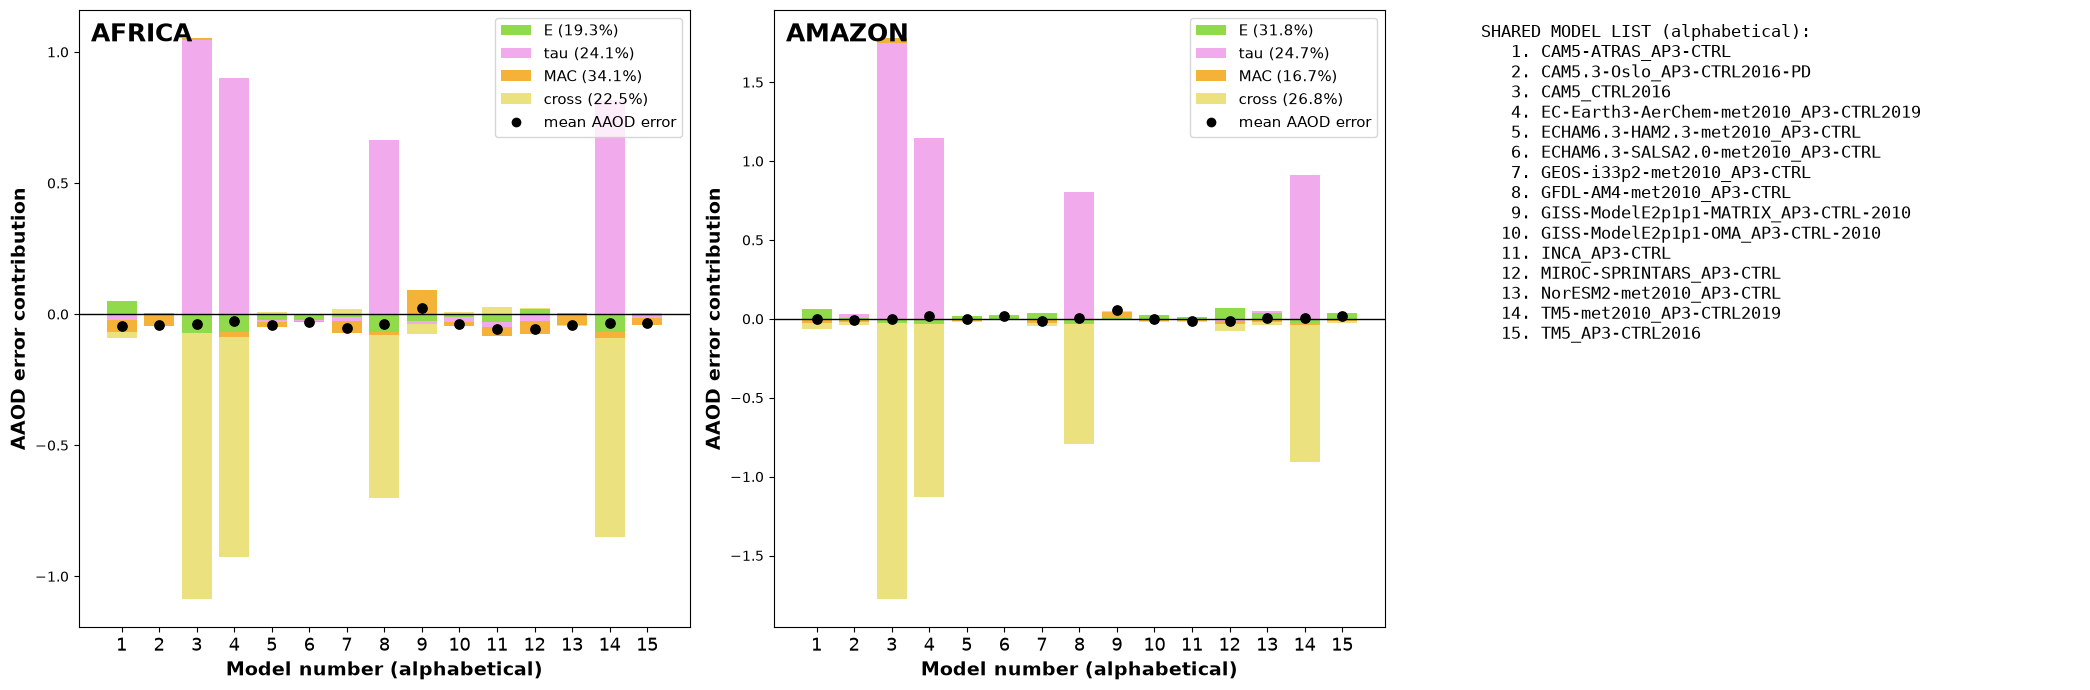

In [23]:
print('\n--- Figure 3 plots (source regions) ---')
colors = {'africa': '#ff7f0e', 'amazon': '#2ca02c', 'outflow_af': '#9467bd'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) MAC vs SSA
ax = axes[0, 0]
for region in SOURCE_REGIONS:
    if region not in mac_ssa_results:
        continue
    sub = reg_df[reg_df['region'] == region].dropna(subset=['MAC', 'SSA'])
    if sub.empty:
        continue
    ax.scatter(sub['SSA'], sub['MAC'], s=25, alpha=0.4, color=colors[region], label=f'{region} model')
    F = mac_ssa_results[region]['F']
    b = mac_ssa_results[region].get('b', 0.0)
    x_line = np.linspace(sub['SSA'].min(), sub['SSA'].max(), 100)
    ax.plot(x_line, F * x_line + b, '--', color=colors[region], linewidth=2,
            label=f'{region}: MAC={F:.2f}*SSA' + (f'+{b:.2f}' if abs(b) > 1e-12 else ''))
    csub = constrained_df[constrained_df['region'] == region]
    if not csub.empty:
        ax.scatter(csub['SSA_obs'].mean(), csub['MAC_c'].mean(), s=150, marker='*',
                   color=colors[region], edgecolors='black', zorder=5, label=f'{region} obs')
ax.set_xlabel('SSA', fontweight='bold')
ax.set_ylabel('MAC (m² g⁻¹)', fontweight='bold')
ax.set_title('(a) MAC vs SSA', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# (b) 1/lifetime vs precip
ax = axes[0, 1]
sc = None
for region in SOURCE_REGIONS:
    sub = reg_df[reg_df['region'] == region].dropna(subset=['inv_lifetime', 'precip', 'AE'])
    if sub.empty:
        continue
    sc = ax.scatter(sub['precip'], sub['inv_lifetime'], c=sub['AE'], cmap='viridis',
                    s=25, alpha=0.5, label=region)
if sc is not None:
    plt.colorbar(sc, ax=ax, label='AE')
ax.set_xlabel('Precipitation (mm/day)', fontweight='bold')
ax.set_ylabel('1 / lifetime (day⁻¹)', fontweight='bold')
ax.set_title('(b) 1/lifetime vs precipitation colored by AE', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# (c) Mean percentage contributions
ax = axes[1, 0]
plot_regions = [r for r in SOURCE_REGIONS if not decomp_df[decomp_df['region'] == r].empty]
x = np.arange(len(plot_regions))
width = 0.2
for i, (col, label, color) in enumerate([
    ('pct_E', 'E', '#1f77b4'),
    ('pct_tau', 'lifetime', '#ff7f0e'),
    ('pct_MAC', 'MAC', '#2ca02c'),
    ('pct_cross', 'cross', '#d62728'),
]):
    vals = [decomp_df[decomp_df['region'] == r][col].mean() for r in plot_regions]
    ax.bar(x + (i - 1.5) * width, vals, width, label=label, color=color)
ax.set_xticks(x)
ax.set_xticklabels([r.upper() for r in plot_regions])
ax.set_ylabel('Mean contribution to |AAOD error| (%)', fontweight='bold')
ax.set_title('(c) Mean error attribution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# (d) Per-model stacked percentages (models in alphabetical order)
ax = axes[1, 1]
for idx, region in enumerate(plot_regions):
    sub = decomp_df[decomp_df['region'] == region].sort_values('model', ascending=True)
    if sub.empty:
        continue
    n = len(sub)
    xpos = np.arange(n) + idx * (n + 1)
    ax.bar(xpos, sub['pct_E'], label='E' if idx == 0 else '', color='#1f77b4')
    ax.bar(xpos, sub['pct_tau'], bottom=sub['pct_E'], label='lifetime' if idx == 0 else '', color='#ff7f0e')
    ax.bar(xpos, sub['pct_MAC'], bottom=sub['pct_E'] + sub['pct_tau'],
           label='MAC' if idx == 0 else '', color='#2ca02c')
    ax.bar(xpos, sub['pct_cross'], bottom=sub['pct_E'] + sub['pct_tau'] + sub['pct_MAC'],
           label='cross' if idx == 0 else '', color='#d62728')
ax.set_ylabel('Contribution to |AAOD error| (%)', fontweight='bold')
ax.set_xlabel('Model (alphabetical)', fontweight='bold')
ax.set_title('(d) AAOD error decomposition', fontweight='bold')
ax.set_xticks([])
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Figure 3: Source-region error attribution (Zhong et al. 2023)', fontsize=15, fontweight='bold')
plt.tight_layout()
fig_path = project_root / 'notebooks' / 'figure3_error_attribution.png'
if SAVE_FIGURE:
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {fig_path}')
plt.close(fig)


# Per-region signed error bars (Fig. 3 detail); shared alphabetical model list
plot_regions = SOURCE_REGIONS
fig, axes = plt.subplots(1, len(plot_regions) + 1, figsize=(7 * (len(plot_regions) + 1), 7))
common_model_list = sorted(decomp_df['model'].unique().tolist())
for idx, region in enumerate(plot_regions):
    ax = axes[idx]
    sub = decomp_df[decomp_df['region'] == region].copy()
    if sub.empty:
        ax.set_visible(False)
        continue
    # Align all regions to the same alphabetical model order
    sub = sub.set_index('model').reindex(common_model_list).reset_index()

    model_aod = aggregate_region(data_derived, 'abs550aer', region, return_time_series=False)
    obs_aod_mean = float(aaod_obs_by_region.get(region, np.nan))
    sub['AAOD_error'] = sub['model'].map(
        lambda m: float(model_aod[m]) - obs_aod_mean if m in model_aod else np.nan
    )
    x = np.arange(len(sub))
    pos_bottom = np.zeros(len(sub))
    neg_bottom = np.zeros(len(sub))
    pct_E_mean = sub['pct_E'].mean(skipna=True)
    pct_tau_mean = sub['pct_tau'].mean(skipna=True)
    pct_MAC_mean = sub['pct_MAC'].mean(skipna=True)
    pct_cross_mean = sub['pct_cross'].mean(skipna=True)
    components = [
        ('dAAOD_E', f'E ({pct_E_mean:.1f}%)', '#90da4b'),
        ('dAAOD_tau', f'tau ({pct_tau_mean:.1f}%)', '#f1abed'),
        ('dAAOD_MAC', f'MAC ({pct_MAC_mean:.1f}%)', '#f4b238'),
        ('dAAOD_cross', f'cross ({pct_cross_mean:.1f}%)', '#ebe27f'),
    ]
    for col, label, color in components:
        vals = sub[col].to_numpy(dtype=float)
        vals = np.nan_to_num(vals, nan=0.0)
        bottoms = np.where(vals >= 0, pos_bottom, neg_bottom)
        ax.bar(x, vals, bottom=bottoms, color=color, width=0.8)
        pos_bottom = np.where(vals >= 0, pos_bottom + vals, pos_bottom)
        neg_bottom = np.where(vals < 0, neg_bottom + vals, neg_bottom)
    ax.scatter(x, sub['AAOD_error'], color='black', s=45, zorder=5)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(np.arange(1, len(sub) + 1), fontsize=13)
    ax.set_ylabel('AAOD error contribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model number (alphabetical)', fontsize=14, fontweight='bold')
    ax.text(0.02, 0.98, region.upper(), transform=ax.transAxes, va='top', ha='left',
            fontsize=18, fontweight='bold')
    ax.legend(handles=[
        Patch(facecolor='#90da4b', label=f'E ({pct_E_mean:.1f}%)'),
        Patch(facecolor='#f1abed', label=f'tau ({pct_tau_mean:.1f}%)'),
        Patch(facecolor='#f4b238', label=f'MAC ({pct_MAC_mean:.1f}%)'),
        Patch(facecolor='#ebe27f', label=f'cross ({pct_cross_mean:.1f}%)'),
        Line2D([0], [0], marker='o', color='black', linestyle='None', label='mean AAOD error'),
    ], loc='upper right', fontsize=11)

ax_legend = axes[-1]
ax_legend.axis('off')
legend_lines = ['SHARED MODEL LIST (alphabetical):']
for i, model in enumerate(common_model_list or [], start=1):
    legend_lines.append(f'  {i:>2d}. {model}')
ax_legend.text(0.02, 0.98, '\n'.join(legend_lines), transform=ax_legend.transAxes,
               va='top', ha='left', fontsize=12, family='monospace')
plt.tight_layout()
fig_path = project_root / 'notebooks' / 'figure3_error_attribution_by_region.png'
if SAVE_FIGURE:
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {fig_path}')
    plt.close(fig)



 ## Outflow prediction plot: model vs meta-fit vs constrained vs POLDER

In [15]:
print('\n--- Outflow prediction plot ---')
if outflow_pred_df.empty:
    print('  No outflow predictions to plot.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(outflow_pred_df['AAOD_model'], outflow_pred_df['AAOD_meta_fit'],
               s=40, alpha=0.8, label='meta-fit vs model')
    lims = [
        min(outflow_pred_df['AAOD_model'].min(), outflow_pred_df['AAOD_meta_fit'].min()) * 0.9,
        max(outflow_pred_df['AAOD_model'].max(), outflow_pred_df['AAOD_meta_fit'].max()) * 1.1,
    ]
    ax.plot(lims, lims, 'k--', alpha=0.5)
    ax.set_xlabel('Model AAOD (outflow)', fontweight='bold')
    ax.set_ylabel('Meta-model fitted AAOD', fontweight='bold')
    title_r2 = outflow_meta_params['r2'] if outflow_meta_params else np.nan
    ax.set_title(f'(a) Meta-model fit (R²={title_r2:.3f})', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axes[1]
    sub = outflow_pred_df.sort_values('model', ascending=True).reset_index(drop=True)
    x = np.arange(len(sub))
    ax.scatter(x, sub['AAOD_model'], label='Model', s=40)
    ax.scatter(x, sub['AAOD_meta_fit'], label='Meta-fit', s=40, marker='s')
    ax.axhline(sub['AAOD_constrained'].iloc[0], color='green', linestyle='--',
               linewidth=2, label='Constrained prediction')
    ax.axhline(sub['AAOD_obs'].iloc[0], color='red', linestyle=':',
               linewidth=2, label='POLDER')
    ax.set_xticks(x)
    ax.set_xticklabels(np.arange(1, len(sub) + 1))
    ax.set_xlabel('Model number (alphabetical)', fontweight='bold')
    ax.set_ylabel('Outflow AAOD', fontweight='bold')
    ax.set_title('(b) Outflow AAOD: model / meta / constrained / POLDER', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.suptitle('African outflow as meta-model prediction target', fontweight='bold')
    plt.tight_layout()
    fig_path = project_root / 'notebooks' / 'figure3_outflow_meta_prediction.png'
    if SAVE_FIGURE:
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f'Saved: {fig_path}')
    plt.close(fig)

    if outflow_meta_params:
        print(f"  Outflow meta-model R²={outflow_meta_params['r2']:.3f}, "
              f"NMB={outflow_meta_params['nmb']:.1f}%, RMSE={outflow_meta_params['rmse']:.5f}")




--- Outflow prediction plot ---
  Outflow meta-model R²=0.961, NMB=0.0%, RMSE=0.00286


 ## Save CSV outputs

In [16]:
out_csv = project_root / 'notebooks' / 'figure3_regression_data.csv'
reg_df.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')

out_csv = project_root / 'notebooks' / 'figure3_constrained_estimates.csv'
constrained_df.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')

out_csv = project_root / 'notebooks' / 'figure3_error_decomposition.csv'
decomp_df.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')

if not outflow_pred_df.empty:
    out_csv = project_root / 'notebooks' / 'figure3_outflow_meta_predictions.csv'
    outflow_pred_df.to_csv(out_csv, index=False)
    print(f'Saved: {out_csv}')

out_csv = project_root / 'notebooks' / 'figure3_model_region_data.csv'
model_region_rows = []
for region in SOURCE_REGIONS + [OUTFLOW_REGION]:
    for model in models:
        row = {'region': region, 'model': model}
        for var in ['MEC', 'MAC', 'SSA', 'AE', 'lifetime_BC_OA', 'precip', 'emi_BC_OA', 'abs550aer']:
            val = model_seasonal[region].get(var, {}).get(model)
            row[var] = float(val) if val is not None and np.isfinite(float(val)) else np.nan
        model_region_rows.append(row)
pd.DataFrame(model_region_rows).to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')

print('\n=== Final configuration diagnostics ===')
print(f'INTERCEPT_0={INTERCEPT_0}, POLDER_HOMOGENIZE={POLDER_HOMOGENIZE}, '
      f'INCLUDE_AMAZON_SOA={INCLUDE_AMAZON_SOA} (f={AMAZON_SOA_FRACTION})')
print('\nMean source-region decomposition:')
print(mean_decomp)
print('\nDone.')


Saved: /scistor/guest/gbb083/AeroCom/notebooks/figure3_regression_data.csv
Saved: /scistor/guest/gbb083/AeroCom/notebooks/figure3_constrained_estimates.csv
Saved: /scistor/guest/gbb083/AeroCom/notebooks/figure3_error_decomposition.csv
Saved: /scistor/guest/gbb083/AeroCom/notebooks/figure3_outflow_meta_predictions.csv
Saved: /scistor/guest/gbb083/AeroCom/notebooks/figure3_model_region_data.csv

=== Final configuration diagnostics ===
INTERCEPT_0=False, POLDER_HOMOGENIZE=True, INCLUDE_AMAZON_SOA=True (f=0.52)

Mean source-region decomposition:
            pct_E    pct_tau    pct_MAC  pct_cross
region                                            
africa  19.286068  24.113873  34.120800  22.479259
amazon  31.788733  24.707533  16.659067  26.844667

Done.
